# First Notebook

This first activity will use basic python to load and visualize data. We will:

- Load two datasets
- Perform any necessary data cleaning
- Reshape/Resample/Merge as needed
- Calculate basic descriptives
- Plot the data

The data is available in ```notebook_1_files``` folder.

*Make sure the folder is in the same directory as this notebook.*

This Notebook has **parts** of the code you need to to the tasks above. Follow the notes to complete or write the pieces of code you may need to finish.



In [ ]:
# Verify this line runs correctly.
# Otherwise, install pandas via conda or pip

import pandas as pd

Load the GDP data

In [ ]:

df_gdp = pd.read_csv('notebook_1_files/gdp.csv',
                     index_col='date',
                     parse_dates=True)

# Observe the data
df_gdp.tail(5)

,gdp
date,
2015-03-31,2978.5
2015-06-30,3060.3
2015-09-30,3033.5
2015-12-31,3001.6
2016-03-31,2963.6
2016-06-30,3086.2
2016-09-30,2985.1
2016-12-31,2922.9
2017-03-31,2979.9


**COMPLETE.**

Load the stock data.

In [ ]:
df_stock = 

df_stock.tail(5)

,fred_SP500
date,
1971-01-01,NaN
1971-01-02,NaN
1971-01-03,NaN
1971-01-04,NaN
1971-01-05,NaN
...,...
2025-03-08,NaN
2025-03-09,NaN
2025-03-10,5614.56


Merge GDP and SP500. Run an outer merge that will include all observations from both datasets.

**COMPLETE**

In [ ]:
df = pd.merge(, on='date',  how='outer')

df.head(10)

,gdp,fred_SP500
date,,
1971-01-01,NaN,NaN
1971-01-02,NaN,NaN
1971-01-03,NaN,NaN
1971-01-04,NaN,NaN
1971-01-05,NaN,NaN
...,...,...
2025-03-08,NaN,NaN
2025-03-09,NaN,NaN
2025-03-10,NaN,5614.56


Notice the data has many missing values

the reason is mixed frequency.

Resample the data into quarterly frequency.

**COMPLETE**: **QS** standds for Quarter Start. **QE** for Quarter End.

In [ ]:
df = df.resample().mean()
df.tail(10)

,gdp,fred_SP500
date,,
1971-03-31,NaN,NaN
1971-06-30,NaN,NaN
1971-09-30,NaN,NaN
1971-12-31,NaN,NaN
1972-03-31,NaN,NaN
...,...,...
2024-03-31,NaN,4992.540984
2024-06-30,NaN,5246.626508
2024-09-30,NaN,5543.469219


You will notice your data has many missing values because GDP data finishes in 2023 but stocks are available until 2025. Let's keep only the columns where there are no missing values.

In [ ]:
df = df.dropna(how='all', axis=0)
df.tail(10)

,gdp,fred_SP500
date,,
2015-03-31,2978.5,2079.539231
2015-06-30,3060.3,2101.829048
2015-09-30,3033.5,2027.200000
2015-12-31,3001.6,2052.311875
2016-03-31,2963.6,1951.224918
2016-06-30,3086.2,2075.131563
2016-09-30,2985.1,2162.056875
2016-12-31,2922.9,2184.878571
2017-03-31,2979.9,2325.927903


There are still missing values because we used the ```how='all'``` parameter. Let's use ```how='any'``` instead.

**COMPLETE**

In [ ]:
df = df.dropna(how=, axis=0)
df

,gdp,fred_SP500
date,,
2015-03-31,2978.5,2079.539231
2015-06-30,3060.3,2101.829048
2015-09-30,3033.5,2027.200000
2015-12-31,3001.6,2052.311875
2016-03-31,2963.6,1951.224918
2016-06-30,3086.2,2075.131563
2016-09-30,2985.1,2162.056875
2016-12-31,2922.9,2184.878571
2017-03-31,2979.9,2325.927903


**COMPLETE:** Descriptive statistics here

In [ ]:
df

,gdp,fred_SP500
count,36.000000,36.000000
mean,2993.908333,3125.656498
std,266.339979,875.341056
min,2159.000000,1951.224918
25%,2955.800000,2379.960190
50%,3004.750000,2907.007698
75%,3150.300000,3985.279449
max,3364.900000,4602.108906


**COMPLETE**: Can we plot?

<Axes: xlabel='date'>

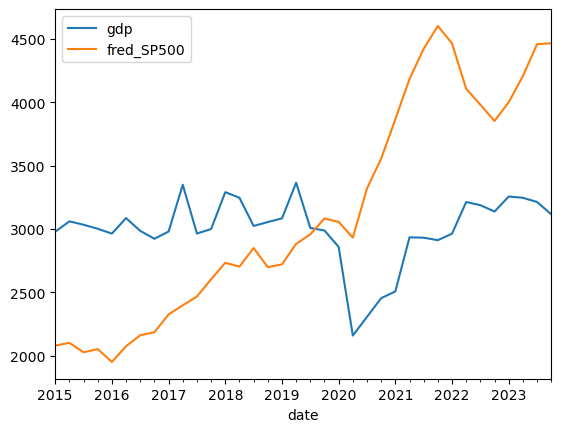

In [25]:
df.plot()

Yes, but we may want to make the comparison meaningful. Let's normalize both series to the QoQ rate of change.

In [30]:
df_change = df.pct_change()
df_change.head(5)

,gdp,fred_SP500
date,,
2015-03-31,NaN,NaN
2015-06-30,0.027463,0.010719
2015-09-30,-0.008757,-0.035507
2015-12-31,-0.010516,0.012387
2016-03-31,-0.012660,-0.049255


**COMPLETE:** Plot

<Axes: xlabel='date'>

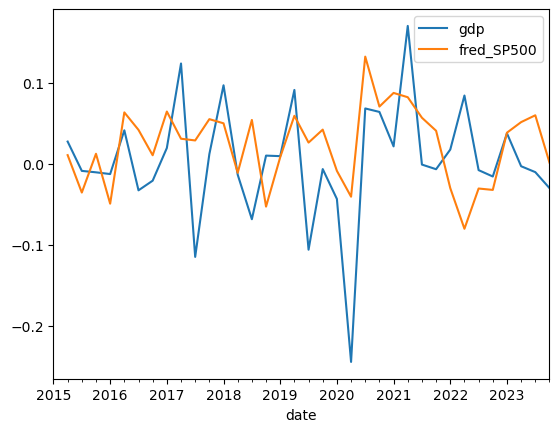

In [ ]:
df_change